# 10 — CGM Daily Means × Family History Risk Level

**Purpose**: Test whether family history of diabetes (none / one relative / multiple
relatives) predicts mean glucose, and whether the Level-2 effect persists after
controlling for study group.

**Inputs**: `features_with_cluster.csv`  
**Output**: `data/processed/10_family_history_summary.csv`


In [3]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['scipy', 'seaborn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
CLUSTER_MAP       = {0: 'Cardiometabolic', 1: 'Musculoskeletal-Inflammatory'}
FH_MAP            = {0: 'No history', 1: 'One relative', 2: 'Multiple relatives'}

# ── Mount Google Drive (persistent across independent kernels) ────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print('Environment ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready.


In [4]:
# ── 2. Load Feature Files ─────────────────────────────────────────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')

# Derive study_group_label from code if missing (e.g. stale CSV from nb07)
if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
features['fh_label'] = features['family_risk_level'].map(FH_MAP)
features['fh_label'] = pd.Categorical(
    features['fh_label'],
    categories=['No history', 'One relative', 'Multiple relatives'], ordered=True)

print(f'features: {features.shape}')
print(features['fh_label'].value_counts().sort_index().to_string())


features: (2245, 23)
fh_label
No history             908
One relative           124
Multiple relatives    1213


## 3. Distribution Analysis

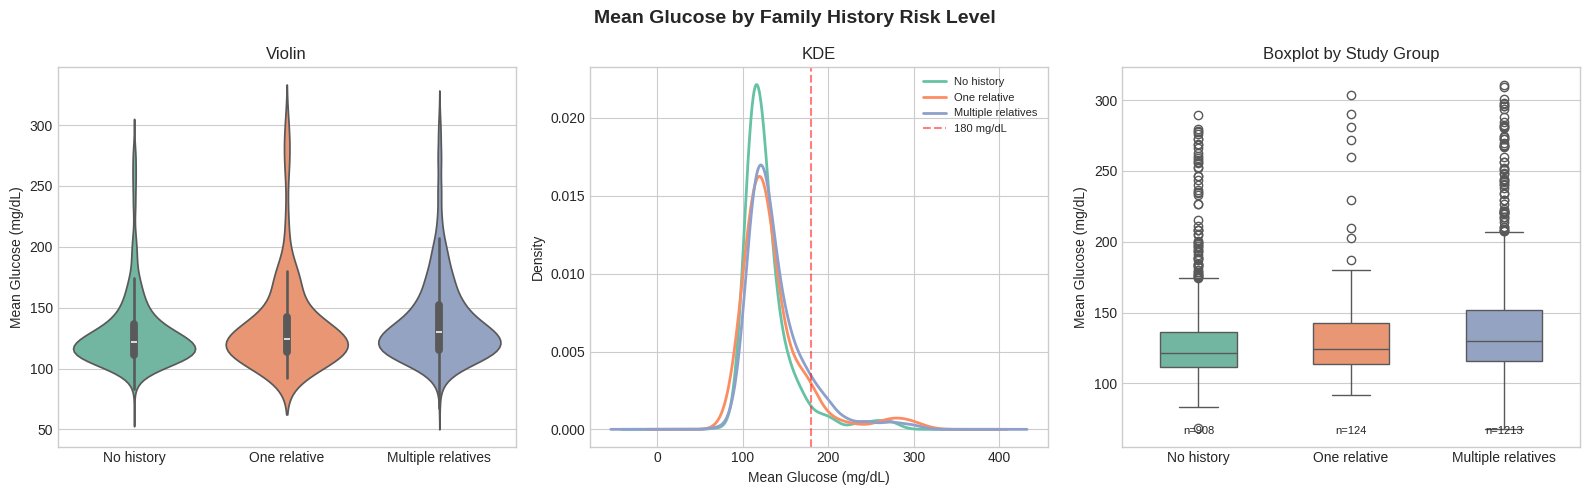

In [5]:
# ── 3a. Violin + KDE + Boxplot ───────────────────────────────────────────
df = features.dropna(subset=['fh_label', 'mean_glucose']).copy()
FH_ORDER = ['No history', 'One relative', 'Multiple relatives']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mean Glucose by Family History Risk Level', fontsize=14, fontweight='bold')

sns.violinplot(data=df, x='fh_label', y='mean_glucose',
               order=FH_ORDER, palette='Set2', inner='box', ax=axes[0])
axes[0].set_title('Violin')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Glucose (mg/dL)')

for fh in FH_ORDER:
    subset = df[df['fh_label'] == fh]['mean_glucose'].dropna()
    subset.plot.kde(ax=axes[1], label=fh, linewidth=2)
axes[1].axvline(180, color='red', linestyle='--', alpha=0.5, label='180 mg/dL')
axes[1].set_title('KDE')
axes[1].set_xlabel('Mean Glucose (mg/dL)')
axes[1].legend(fontsize=8)

sns.boxplot(data=df, x='fh_label', y='mean_glucose',
            order=FH_ORDER, palette='Set2', width=0.5, ax=axes[2])
axes[2].set_title('Boxplot by Study Group')
for fh in FH_ORDER:
    n = (df['fh_label'] == fh).sum()
    xi = FH_ORDER.index(fh)
    axes[2].text(xi, df['mean_glucose'].min() - 3, f'n={n}', ha='center', fontsize=8)
axes[2].set_xlabel('')
axes[2].set_ylabel('Mean Glucose (mg/dL)')

plt.tight_layout()
plt.show()


=== % with family_risk_level == 2 by study group ===
study_group_label
Healthy    36.400
Pre-DM     52.900
Oral Med   69.600
Insulin    67.700


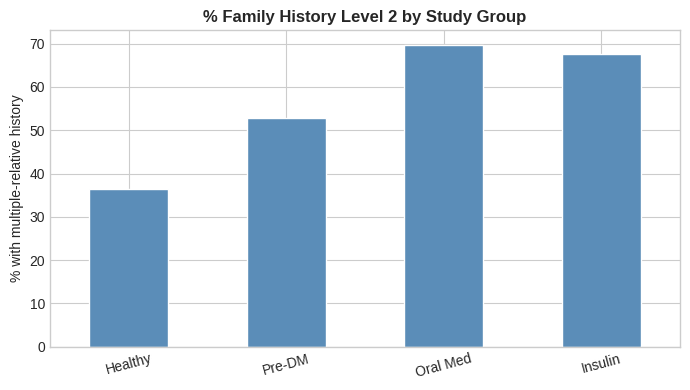

In [6]:
# ── 3b. By Study Group: prevalence of family history level 2 ─────────────
prev = (features.dropna(subset=['study_group_label'])
        .groupby('study_group_label', observed=True)['family_risk_level']
        .apply(lambda x: (x == 2).sum() / len(x) * 100)
        .rename('pct_level2'))
print('=== % with family_risk_level == 2 by study group ===')
print(prev.round(1).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
prev.plot.bar(ax=ax, color='#5b8db8', edgecolor='white')
ax.set_title('% Family History Level 2 by Study Group', fontweight='bold')
ax.set_ylabel('% with multiple-relative history')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


## 4. Statistical Tests

In [7]:
# ── 4a. Kruskal-Wallis across 3 FH levels ───────────────────────────────
groups = [df[df['fh_label'] == fh]['mean_glucose'].dropna().values for fh in FH_ORDER]
stat, p_kw = stats.kruskal(*groups)
print(f'Kruskal-Wallis H={stat:.3f}  p={p_kw:.2e}')

# Level 0 vs Level 2 focal comparison
a = df[df['family_risk_level'] == 0]['mean_glucose'].dropna()
b = df[df['family_risk_level'] == 2]['mean_glucose'].dropna()
u, p_02 = stats.mannwhitneyu(a, b, alternative='two-sided')
d = (b.mean() - a.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2)
print(f'\nLevel 0 vs Level 2 (focal comparison):')
print(f'  Level 0: mean={a.mean():.1f} SD={a.std():.1f} n={len(a):,}')
print(f'  Level 2: mean={b.mean():.1f} SD={b.std():.1f} n={len(b):,}')
print(f'  Mann-Whitney U={u:.0f}  p={p_02:.4f}  Cohens d={d:.3f}')


Kruskal-Wallis H=63.712  p=1.46e-14

Level 0 vs Level 2 (focal comparison):
  Level 0: mean=129.6 SD=31.2 n=908
  Level 2: mean=139.5 SD=36.2 n=1,213
  Mann-Whitney U=439474  p=0.0000  Cohens d=0.290


In [8]:
# ── 4b. Study-group-adjusted comparison ──────────────────────────────────
# Within each study group: does FH Level 2 predict higher glucose?
print('=== Within-group: Level 0 vs Level 2 mean glucose ===\n')
print(f'{"Study Group":<12}  {"L0 mean":>8}  {"L2 mean":>8}  {"diff":>7}  {"p":>8}  sig')
print('-' * 60)

adj_results = []
for grp in STUDY_GROUP_ORDER:
    sub = features[features['study_group_label'] == grp].dropna(subset=['family_risk_level', 'mean_glucose'])
    a = sub[sub['family_risk_level'] == 0]['mean_glucose']
    b = sub[sub['family_risk_level'] == 2]['mean_glucose']
    if len(a) > 5 and len(b) > 5:
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        diff = b.mean() - a.mean()
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{grp:<12}  {a.mean():>8.1f}  {b.mean():>8.1f}  {diff:>+7.1f}  {p:>8.4f}  {sig}')
        adj_results.append({'study_group': grp, 'n_L0': len(a), 'n_L2': len(b),
                             'mean_L0': round(a.mean(),2), 'mean_L2': round(b.mean(),2),
                             'diff': round(diff,2), 'p': round(p,5)})


=== Within-group: Level 0 vs Level 2 mean glucose ===

Study Group    L0 mean   L2 mean     diff         p  sig
------------------------------------------------------------
Healthy          117.4     118.4     +1.1    0.4217  ns
Pre-DM           123.8     127.0     +3.2    0.0893  ns
Oral Med         146.5     147.9     +1.4    0.9319  ns
Insulin          183.1     171.6    -11.5    0.1286  ns


## 5. Summary Table & Export

In [9]:
summary = (
    df.groupby('fh_label', observed=True)['mean_glucose']
    .agg(n='count', mean='mean', std='std', median='median',
         pct_gt_180=lambda x: (x > 180).mean() * 100)
    .round(2).reset_index()
)
summary.columns = ['Family History Level', 'N', 'Mean (mg/dL)', 'SD', 'Median', '% > 180 mg/dL']
print(summary.to_string(index=False))

summary.to_csv(out_dir / '10_family_history_summary.csv', index=False)
print('\nSaved 10_family_history_summary.csv')


Family History Level    N  Mean (mg/dL)     SD  Median  % > 180 mg/dL
          No history  908       129.640 31.190 121.740          6.060
        One relative  124       136.000 38.940 124.210          8.060
  Multiple relatives 1213       139.450 36.180 129.740         11.380

Saved 10_family_history_summary.csv


## 6. Key Findings

- **Omnibus test**: Kruskal-Wallis H = 63.7, p = 1.46e-14 — mean glucose differs significantly across the three family history levels.
- **Focal comparison (Level 0 vs Level 2)**: Participants with multiple relatives with diabetes (n=1,213) had meaningfully higher mean glucose (139.5 mg/dL, SD=36.2) than those with no family history (n=908; 129.6 mg/dL, SD=31.2) — Mann-Whitney p < 0.0001, Cohen's d = 0.290 (small-to-medium effect).
- **Threshold exceedance**: % of daily means > 180 mg/dL increases with family history burden — No history: 6.1%, One relative: 8.1%, Multiple relatives: 11.4%.
- **Study-group-adjusted analysis**: The Level 0 vs Level 2 gap is not significant within any individual study group (Healthy: +1.1 mg/dL p=0.42 ns; Pre-DM: +3.2 mg/dL p=0.09 ns; Oral Med: +1.4 mg/dL p=0.93 ns; Insulin: −11.5 mg/dL p=0.13 ns), indicating the overall family history effect is largely confounded by disease severity (Level 2 is enriched in more severe groups).
- **Interpretation**: Family history risk level predicts mean glucose at the population level, but this association appears to be driven primarily by its correlation with study group membership rather than an independent biological effect.
